In [1]:
import os
import sys; sys.path.append('..')
import MeshFEM, mesh, inflation, visualization, sheet_meshing
from tri_mesh_viewer import TriMeshViewer as Viewer
import numpy as np, importlib
import sheet_optimizer, utils
from matplotlib import pyplot as plt
import matplotlib, vis
import measurements
import glob

In [2]:
# Get the number of iterates taken by each optimization (with/without resume)
for i in glob.glob('benchmark_results/opt_*.pkl.gz'):
    sheet_opt = utils.load(i)
    print(f'{i}:\t{len(sheet_opt.report.energies)}')

benchmark_results/opt_lilium.pkl.gz:	832
benchmark_results/opt_hunchback_cashew.pkl.gz:	1314
benchmark_results/opt_squidward.pkl.gz:	731
benchmark_results/opt_cast.pkl.gz:	1001
benchmark_results/opt_mask.pkl.gz:	148
benchmark_results/opt_helmet.pkl.gz:	1001
benchmark_results/opt_lilium.resumed.pkl.gz:	1028
benchmark_results/opt_squidward.resumed.pkl.gz:	1079
benchmark_results/opt_annulus.pkl.gz:	1665


In [3]:
models = {'annulus': 'data/remeshed_annulus_sheet_opt.pkl.gz',
          'cast': 'Cast/data/cast_larger.opt.pkl.gz',
          'helmet': 'Helmet/megamonster/Helmet/data/helmet_medium.opt.pkl.gz',
          'hunchback_cashew': 'data/hunchback_cashew_sm0.1_narrowwall_continue.pkl.gz',
          'lilium': 'data/lilium_remeshed_sheet_opt_cp_25_smooth_0.1_interior_0.1.pkl.gz',
          'squidward': 'data/squidward_fixedbdry_sm0.1.pkl.gz',
          'mask': 'data/mask_nofit_hohcp_opt_2.pkl.gz'}

In [4]:
originalOptimizationDists = {}
benchmarkOptimizationDists = {}

In [5]:
# Compute distances to the target surface for the original (fabricated) results
for k, origOpt in models.items():
    opt = utils.load(origOpt)
    tas = opt.rso.targetAttractedInflation()
    dists = measurements.getApproxMidsurfaceDistances(tas.sheet(), utils.getTargetSurf(tas), relative=True)
    originalOptimizationDists[k] = [np.max(dists), np.percentile(dists, 98), np.percentile(dists, 99), np.percentile(dists, 99.5), dists]

In [6]:
for k in models.keys():
    resumedPath =  f'benchmark_results/opt_{k}.resumed.pkl.gz'
    path = resumedPath if os.path.exists(resumedPath) else f'benchmark_results/opt_{k}.pkl.gz'
    opt = utils.load(path)
    tas = opt.rso.targetAttractedInflation()
    dists = measurements.getApproxMidsurfaceDistances(tas.sheet(), utils.getTargetSurf(tas), relative=True)
    benchmarkOptimizationDists[k] = [np.max(dists), np.percentile(dists, 98), np.percentile(dists, 99), np.percentile(dists, 99.5)]

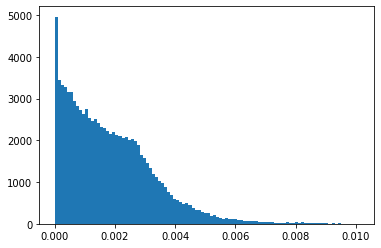

In [7]:
plt.hist(originalOptimizationDists['annulus'][-1], bins=100);

In [115]:
originalOptimizationDists

{'annulus': [0.010099878684266768,
  0.005515272781175444,
  0.006433740660075017,
  0.007339466658792922],
 'cast': [0.008878833013534485,
  0.004400091585595001,
  0.004990235671615556,
  0.005648547914192039],
 'helmet': [0.00791246357445227,
  0.0034239262197544784,
  0.0038613321294387196,
  0.004371870582412236],
 'hunchback_cashew': [0.009121056996784492,
  0.00539805898816057,
  0.005908179181021919,
  0.006362742677638913],
 'lilium': [0.006846807002548348,
  0.004345166660076406,
  0.004868581079783867,
  0.005202230913522871],
 'squidward': [0.008204541211506317,
  0.003953983588706194,
  0.004429951924429644,
  0.005200112633237703],
 'mask': [0.006514463136945704,
  0.0029042506058837188,
  0.0034975216524982733,
  0.004081969824950885]}

In [8]:
benchmarkOptimizationDists

{'annulus': [0.010773348823830499,
  0.005051246386171666,
  0.006015710066851601,
  0.00712559848358084],
 'cast': [0.00882993709691709,
  0.00437750243396425,
  0.004954677334407601,
  0.005589077316553693],
 'helmet': [0.007875371006480544,
  0.0034178831306231885,
  0.0038650405956678173,
  0.004337111728343547],
 'hunchback_cashew': [0.005723512436584833,
  0.0035272156438433486,
  0.0040212686627896475,
  0.004443786723367782],
 'lilium': [0.00886002151708986,
  0.0058423162616428465,
  0.006408390241242854,
  0.007139262104056059],
 'squidward': [0.00956020081758042,
  0.006349321152699301,
  0.007538775324549026,
  0.00864773380797421],
 'mask': [0.01214382890538945,
  0.007521577612826727,
  0.008566197015611022,
  0.009393591894671548]}

We note the benchmarking optimizations generally did about the same as the originals (cashew did much better, lilium/squidward slightly worse).
The mask actually did better in the benchmarking optmization, but an i/o bug at the end of the original resume script prevented the result from getting written out :(
However, in order for the table to reflect fitting values for the exact prototypes that were fabricated, we use dists from the original set.

In [9]:
sorted_models = sorted(models.keys(), key=lambda name: utils.load(f'benchmark_results/{name}.pkl.gz')['sim_dof'])

In [31]:
import time
def tfmt(t):
    tt = time.gmtime(t)
    return time.strftime('%-H:%M:%S', tt) if t > 60 * 60 else (time.strftime('%-M:%S', tt))
    return time.strftime('%-H:%M:%S', tt) if t > 60 * 60 else (time.strftime('%-M:%S', tt) if t > 60 else time.strftime('%S'))

In [24]:
import datetime
str(datetime.timedelta(seconds=65)

'0:01:05'

In [27]:
tfmt(64)

'1:04'

In [44]:
print(f"{'name':>20} {'sim dof':>8} {'opt dof':>8} {'param':>9} {'stripe':>8} {'equi':>8} {'opt':>10} {'sim fit (mean)':>14} {'sim fit (99%)':>15} {'sim fit (max)':>14}")
for model in sorted_models:
    b = utils.load(f'benchmark_results/{model}.pkl.gz')
    print(f"{model:>20} {b['sim_dof']:>8} {b['opt_dof'][0]:>8} ", end='')
    bb = b['benchmarks']
    opt_time = bb['optimization'][0]
    #print('old opt_time: ', opt_time)
    try:
        rb = utils.load(f'benchmark_results/resumed_benchmark_{model}.pkl.gz')
        if 'optimization' in rb: opt_time += rb['optimization'] # manually recovered mask case...
        else:                    opt_time += rb[''][0] # resume script outputs the benchmark dict directly
        #print('new opt_time: ', opt_time)
    except: pass
    print(f"{tfmt(bb['param'][0]):>9}", end='')
    print(f"{tfmt(bb['stripe'][0] + bb['meshing'][0]):>9}", end='')
    print(f"{tfmt(bb['equilibrium'][0]):>9}", end='')
    print(f"{tfmt(opt_time):>9}", end='')
    print(f"{1000 * originalOptimizationDists[model][-1].mean():16.2f}", end='')
    print(f"{1000 * np.percentile(originalOptimizationDists[model][-1], 99):16.2f}", end='')
    print(f"{1000 * originalOptimizationDists[model][-1].max():15.2f}", end='')
    print('')

                name  sim dof  opt dof     param   stripe     equi        opt sim fit (mean)   sim fit (99%)  sim fit (max)
                cast   398043    35550      1:03     0:32     0:45  1:02:21            1.34            4.99           8.88
    hunchback_cashew   412404    30968      0:46     0:18     0:40  1:40:18            1.85            5.91           9.12
              helmet   416409    36466      2:02     0:37     0:49  1:08:56            0.86            3.86           7.91
           squidward   439245    33878      0:42     0:22     0:44  2:08:55            1.24            4.43           8.20
             annulus   484125    47978      2:11     0:40     0:55  2:38:48            1.83            6.43          10.10
              lilium   503421    48846      1:26     0:26     0:41  2:32:55            1.27            4.87           6.85
                mask  1309785   136834     21:41     1:42     5:02 11:30:01            0.70            3.50           6.51


In [ ]:
import time

In [138]:
print(f"{'name':>20} {'sim dof':>8} {'opt dof':>8} {'param':>9} {'stripe':>8} {'equi':>8} {'opt':>10} {'sim fit (max)':>14} {'sim fit (99.5%)':>15}")
for model in sorted_models:
    b = utils.load(f'benchmark_results/{model}.pkl.gz')
    print(f"{model:>20} {b['sim_dof']:>8} {b['opt_dof'][0]:>8} ", end='')
    bb = b['benchmarks']
    opt_time = bb['optimization'][0]
    #print('old opt_time: ', opt_time)
    try:
        rb = utils.load(f'benchmark_results/resumed_benchmark_{model}.pkl.gz')
        if 'optimization' in rb: opt_time += rb['optimization'] # manually recovered mask case...
        else:                    opt_time += rb[''][0] # resume script outputs the benchmark dict directly
        #print('new opt_time: ', opt_time)
    except: pass
    print(f"{bb['param'][0]:9.2f}", end='')
    print(f"{bb['stripe'][0] + bb['meshing'][0]:9.2f}", end='')
    print(f"{bb['equilibrium'][0]:9.2f}", end='')
    print(f"{opt_time :11.2f}", end='')
    print(f"{originalOptimizationDists[model][-1].max():15.5f}", end='') # get max
    print(f"{np.percentile(originalOptimizationDists[model][-1], 99.5):16.5f}", end='') # get max
    print('')

                name  sim dof  opt dof     param   stripe     equi        opt  sim fit (max) sim fit (99.5%)
                cast   398043    35550     63.35    32.09    45.62    3741.54        0.00888         0.00565
    hunchback_cashew   412404    30968     46.10    18.54    40.19    6018.20        0.00912         0.00636
              helmet   416409    36466    122.23    37.08    49.26    4136.15        0.00791         0.00437
           squidward   439245    33878     42.03    22.97    44.27    7735.63        0.00820         0.00520
             annulus   484125    47978    131.30    40.17    55.35    9528.25        0.01010         0.00734
              lilium   503421    48846     86.73    26.40    41.70    9175.05        0.00685         0.00520
                mask  1309785   136834   1301.95   102.90   302.48   41401.76        0.00651         0.00408
